## Understanding the Ring-Attractor dynamics step by step 

In [2]:
import numpy as np
import matplotlib.pyplot as plt


## RING ATTRACTOR

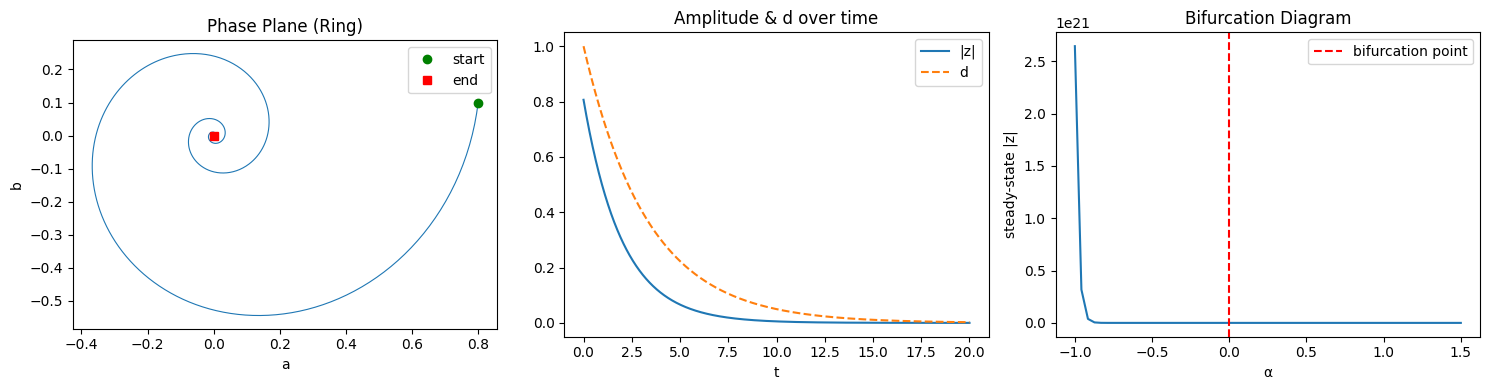

Theoretical period T = 2π/ω = 3.1416


In [4]:
from scipy.integrate import solve_ivp

# --- Parameters ---
alpha = 0.5   # radial damping (try negative to see unstable spiral)
omega = 2.0   # rotation frequency
beta  = 0.3   # decay rate of d channel
dt    = 0.01
T     = 20.0

def single_cell(t, state):
    a, b, d = state
    da = -alpha * a + omega * b   # eq (9), no Laplacian, no input
    db = -alpha * b - omega * a   # eq (10)
    dd = -beta  * d               # eq (11)
    return [da, db, dd]

# Initial condition: small perturbation away from origin
z0 = [0.8, 0.1, 1.0]
sol = solve_ivp(single_cell, [0, T], z0, max_step=dt, dense_output=True)
t   = np.linspace(0, T, 2000)
a, b, d = sol.sol(t)

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Phase plane (a,b)
axes[0].plot(a, b, lw=0.8)
axes[0].plot(a[0], b[0], 'go', label='start')
axes[0].plot(a[-1], b[-1], 'rs', label='end')
axes[0].set_xlabel('a'); axes[0].set_ylabel('b')
axes[0].set_title('Phase Plane (Ring)')
axes[0].legend(); axes[0].set_aspect('equal')

# Amplitude over time
r = np.sqrt(a**2 + b**2)
axes[1].plot(t, r, label='|z|')
axes[1].plot(t, d, label='d', linestyle='--')
axes[1].set_xlabel('t'); axes[1].set_title('Amplitude & d over time')
axes[1].legend()

# Bifurcation: vary alpha, measure steady-state amplitude
alphas = np.linspace(-1, 1.5, 60)
r_ss   = []
for al in alphas:
    def sys(t, s): 
        return [-al*s[0]+omega*s[1], -al*s[1]-omega*s[0], -beta*s[2]]
    s = solve_ivp(sys, [0, 50], [0.5, 0.1, 1.0], max_step=0.01)
    r_ss.append(np.sqrt(s.y[0,-1]**2 + s.y[1,-1]**2))

axes[2].plot(alphas, r_ss)
axes[2].axvline(0, color='r', linestyle='--', label='bifurcation point')
axes[2].set_xlabel('α'); axes[2].set_ylabel('steady-state |z|')
axes[2].set_title('Bifurcation Diagram')
axes[2].legend()

plt.tight_layout()
plt.savefig('stage1_single_cell.png', dpi=150)
plt.show()

# Print period
print(f"Theoretical period T = 2π/ω = {2*np.pi/omega:.4f}")

Amari (1977) have study the dynamics of a network where excitatory and inhibitory neurons coexists. He demostrate how in this cases different pattern can be formed depending on how the network is construct(no. of neurons, stimulus, etx). This give us with a mathematical formal approach on how we can have stable systems of one layer with both kind of neurons instead of having homogeneous layers (Dale's law) and how this lead us with syable systems with patterns. In this notebook we will study further these equations and the dynamics proposed to later apply this knowledge on a Ring Attractor implemented in a NCA framework 

Dale state that neurons should be only excitatory or inhibitory, Amari changes this perspective by applying a weights connection between  this neurons with a function (Mexican Hat) where the nearest neurons act like excitaroty while the farest act as inhibitory 



In [22]:
def mexican_hat(x, sigma):
    return (1 - (x/sigma)**2) * np.exp(-x**2 / (2*sigma**2)) * 2.0

sigma = 1.5
x = np.linspace(-5, 5, 100)
result = mexican_hat(x, sigma)

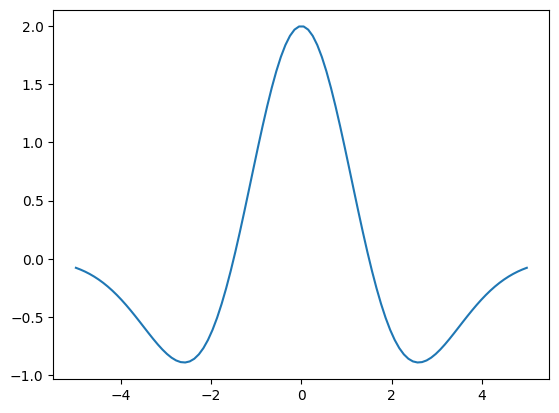

In [23]:
plt.plot(x, result)

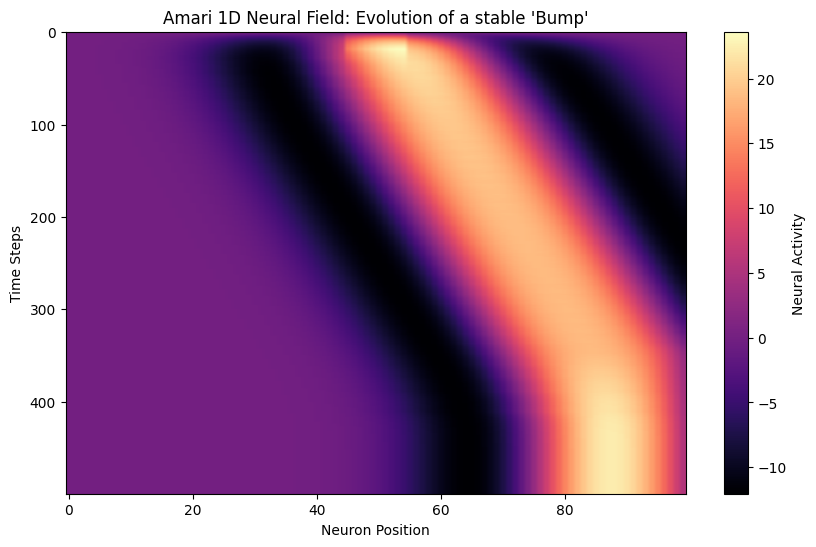

In [ ]:
# Parameters
n = 100            # Number of neurons
dt = 0.1           # Time step
tau = 1.0          # Time constant
steps = 500
sigma = 10.0       # Width of the kernel

x = np.arange(n)
dist = np.minimum(np.abs(x - n//2), n - np.abs(x - n//2))
kernel = (1 - (dist/sigma)**2) * np.exp(-dist**2 / (2*sigma**2)) * 2.0

u = np.zeros(n)    # Potential of neurons
history = []

for t in range(steps):
    # f(u) is the activation function (Heaviside or Sigmoid)
    f_u = np.where(u > 0.5, 1.0, 0.0) 
    
    interaction = np.convolve(f_u, kernel, mode='same')

    stimulus = np.zeros(n)
    if t < 20:
        stimulus[45:55] = 5.0 # Localized input in the center
    
    du = (-u + interaction + stimulus) * (dt / tau)
    u += du
    history.append(u.copy())

plt.figure(figsize=(10, 6))
plt.imshow(history, aspect='auto', cmap='magma')
plt.colorbar(label='Neural Activity')
plt.title("Amari 1D Neural Field Simulation")
plt.xlabel("Neuron Position")
plt.ylabel("Time Steps")
plt.show()

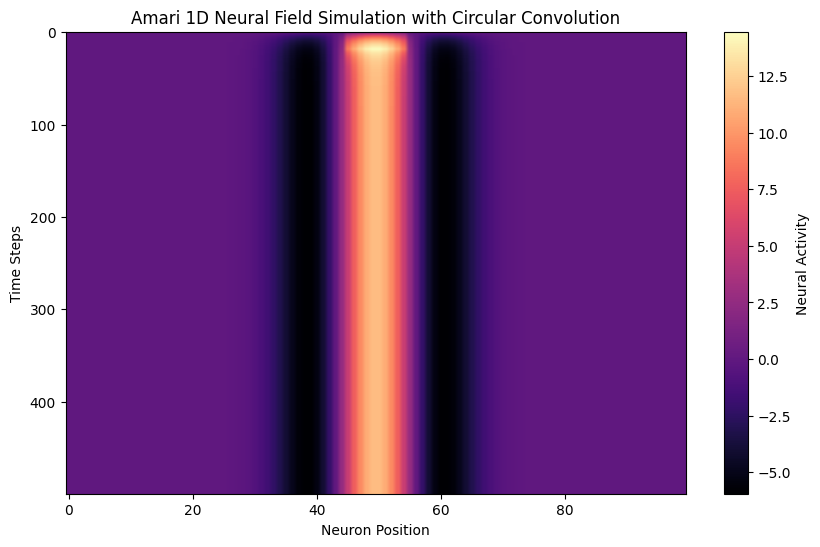

In [24]:
n = 100            
dt = 0.1           
tau = 1.0          
steps = 500
sigma = 5.0        


#We can also compute the amari equations using a circular convolution to approach the ring attratcor dynamics 
x_coords = np.arange(n)
dist = np.abs(x_coords - n//2)
dist = np.where(dist > n//2, n - dist, dist)


kernel = (1 - (dist/sigma)**2) * np.exp(-dist**2 / (2*sigma**2)) * 2.0

u = np.zeros(n)    
history = []

for t in range(steps):
    f_u = np.where(u > 0.2, 1.0, 0.0) 
    
    # CIRCULAR CONVOLUTION is essential for Ring Attractors
    # We use FFT for perfect circularity
    interaction = np.real(np.fft.ifft(np.fft.fft(f_u) * np.fft.fft(np.fft.fftshift(kernel))))

    stimulus = np.zeros(n)
    if t < 20:
        stimulus[45:55] = 5.0 
    
    du = (-u + interaction + stimulus) * (dt / tau)
    u += du
    history.append(u.copy())

plt.figure(figsize=(10, 6))
plt.imshow(history, aspect='auto', cmap='magma')
plt.colorbar(label='Neural Activity')
plt.title("Amari 1D Neural Field Simulation with Circular Convolution")
plt.xlabel("Neuron Position")
plt.ylabel("Time Steps")
plt.show()

We observe in both graphs the bump of the nueurons using the Amari dynamics equations. In the first one, we can see how the neurons fire are activated in the center but as time goes this start moving of position until they look to reach a steady state around the 400 steps in the >80 neurons, this represent that our attractor is moving over time. In the second case we add a circular boundary, with this we are forcing that the kernel output is connected with the kernel input, as we can see this give us a stable attractor over time. This represent the behavior of a ring attractor. In our future work, in the NCA experiment, we will work with the ring attractor as we will apply a slow low-dynamics ring-attractor controller to understand the dynamics of the update rule of the system, as we will work with a vector (perception vector) with 3 channels dedicated to compute the ring phase and the inhibition (competence/injury) value of the neurons. But we need to modify this equations as we will work on a 2D space (grid of neurons) and as they are interacting we have a reaction-diffusion dynamics, our final goal is to demostrate how the local interactions (the grid of 3x3 of the NCA) cna lead us with this global behavior and as a result we have a system that is robust to damage 